### %pip install scikit-learn

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split



# **Loading the Dataset**

In [27]:
import pandas as pd

df = pd.read_csv(House_Rent_Dataset.csv")

df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


In [51]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


# **Handling Missing Value**

In [52]:
df.isna().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [53]:
print('Total numbers of missing values:', df.isna().sum().sum())

Total numbers of missing values: 0


# **Exploratory Data Analysis**

<Axes: xlabel='Tenant Preferred', ylabel='count'>

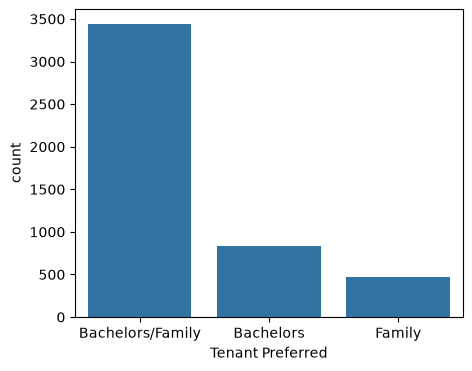

In [54]:
plt.figure(figsize = (5, 4))
sns.countplot(data = df, x = 'Tenant Preferred')

In [55]:
df_house = df.drop(columns = 'Posted On')

In [56]:
df_house.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   BHK                4746 non-null   int64
 1   Rent               4746 non-null   int64
 2   Size               4746 non-null   int64
 3   Floor              4746 non-null   str  
 4   Area Type          4746 non-null   str  
 5   Area Locality      4746 non-null   str  
 6   City               4746 non-null   str  
 7   Furnishing Status  4746 non-null   str  
 8   Tenant Preferred   4746 non-null   str  
 9   Bathroom           4746 non-null   int64
 10  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(7)
memory usage: 408.0 KB


# **Data Encoding**

In [57]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [58]:
df_house.columns

Index(['BHK', 'Rent', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Bathroom',
       'Point of Contact'],
      dtype='str')

In [59]:
names = list(df_house.select_dtypes(include=['object', 'string']).columns)

In [60]:
names

['Floor',
 'Area Type',
 'Area Locality',
 'City',
 'Furnishing Status',
 'Tenant Preferred',
 'Point of Contact']

In [61]:
df_strings = df_house[names]

In [62]:
df_strings.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Floor              4746 non-null   str  
 1   Area Type          4746 non-null   str  
 2   Area Locality      4746 non-null   str  
 3   City               4746 non-null   str  
 4   Furnishing Status  4746 non-null   str  
 5   Tenant Preferred   4746 non-null   str  
 6   Point of Contact   4746 non-null   str  
dtypes: str(7)
memory usage: 259.7 KB


In [63]:
def encoder(col):
    df_house[col] = le.fit_transform(df_strings[col])

In [64]:
for i in names:
    encoder(i)

In [65]:
df_house.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   BHK                4746 non-null   int64
 1   Rent               4746 non-null   int64
 2   Size               4746 non-null   int64
 3   Floor              4746 non-null   int64
 4   Area Type          4746 non-null   int64
 5   Area Locality      4746 non-null   int64
 6   City               4746 non-null   int64
 7   Furnishing Status  4746 non-null   int64
 8   Tenant Preferred   4746 non-null   int64
 9   Bathroom           4746 non-null   int64
 10  Point of Contact   4746 non-null   int64
dtypes: int64(11)
memory usage: 408.0 KB


# **Feature Selection**

<Axes: >

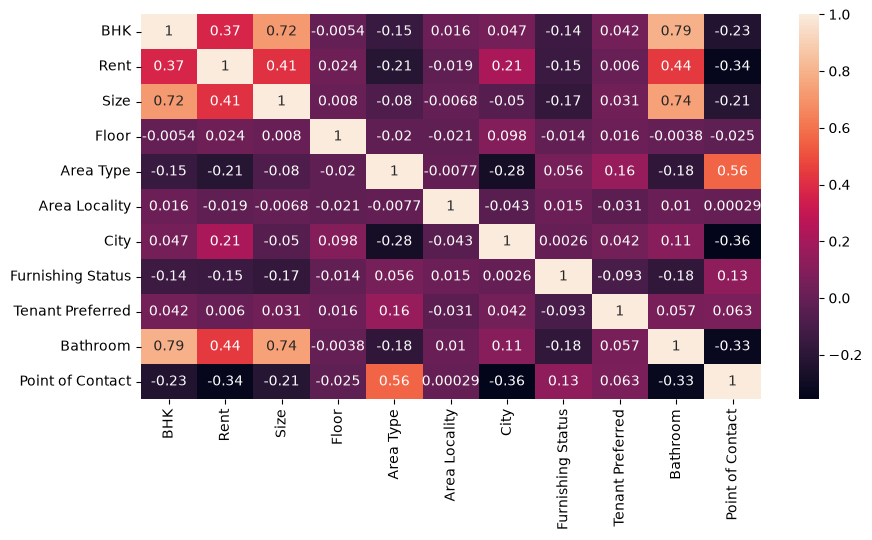

In [66]:
plt.figure(figsize = (10, 5))
sns.heatmap(df_house.corr(), annot = True)

In [67]:
x = df_house[['BHK', 'Size', 'Floor', 'Area Type', 
               'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact']]

In [68]:
y = df_house['Rent']

# **Data Splitting**

In [69]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

In [70]:
print('Total training rows:', x_train.shape[0])
print('Total training columns:', x_train.shape[1])
print('Total training:', y_train.shape[0])
print(x_test.shape)
print(y_test.shape)

Total training rows: 3796
Total training columns: 10
Total training: 3796
(950, 10)
(950,)


# **Building a Machine Learning Model**

In [71]:
model = LinearRegression()

In [72]:
import warnings
warnings.filterwarnings('ignore')
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ -774.97, 30.77, 2.86,..., -1900.24, 16036.61,-13141.51]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['BHK','Size','Floor',...,'Tenant Preferred','Bathroom','Point of Contact']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3715
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)


# **Model Testing**

In [73]:
pred = model.predict(x_test)

In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 2))

MAE: 23028.72
RMSE: 37586.82
R² Score: 0.52


In [75]:
if r2 >= 0.80:
    print("Model Performance: GOOD")
elif r2 >= 0.60:
    print("Model Performance: MODERATE")
else:
    print("Model Performance: BAD")

Model Performance: BAD


In [76]:
print('Maximum Rent:', max(df_house['Rent']))
print('Minimum Rent:', min(df_house['Rent']))
print('Average Rent:', np.mean(df_house['Rent']))

Maximum Rent: 3500000
Minimum Rent: 1200
Average Rent: 34993.45132743363


# **Mean, Median and Mode of Rent**

In [77]:

mean_rent = df_house['Rent'].mean()
median_rent = df_house['Rent'].median()
mode_rent = df_house['Rent'].mode()[0]

print("Mean Rent:", round(mean_rent, 2))
print("Median Rent:", round(median_rent, 2))
print("Mode Rent:", mode_rent)

Mean Rent: 34993.45
Median Rent: 16000.0
Mode Rent: 15000


# **Best Central Tendency**

In [78]:
#The Rent distribution is right-skewed because the Mean Rent (34,993.45) is much higher than the Median Rent (16,000). The data also contains very high rent values, with a maximum Rent of 3,500,000. Therefore, the Median is the best measure of central tendency for the Rent column because it is less affected by extreme values and outliers than the Mean

# **Performance conclusion**

In [79]:
#The Linear Regression model achieved an R² Score of 0.72. Therefore, the model performance is classified as Moderate. This means the model explains a reasonable amount of the variation in Rent values, but there is still room for improvement.

# **Distribution Graph**

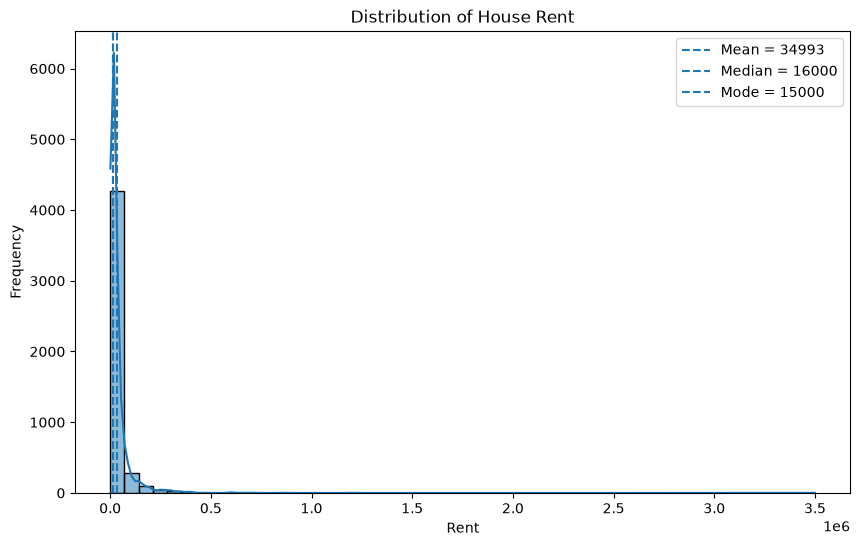

In [80]:
plt.figure(figsize=(10, 6))

sns.histplot(df_house['Rent'], bins=50, kde=True)

plt.axvline(mean_rent, linestyle='--', label=f'Mean = {mean_rent:.0f}')
plt.axvline(median_rent, linestyle='--', label=f'Median = {median_rent:.0f}')
plt.axvline(mode_rent, linestyle='--', label=f'Mode = {mode_rent:.0f}')

plt.title('Distribution of House Rent')
plt.xlabel('Rent')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# **Boxplot**

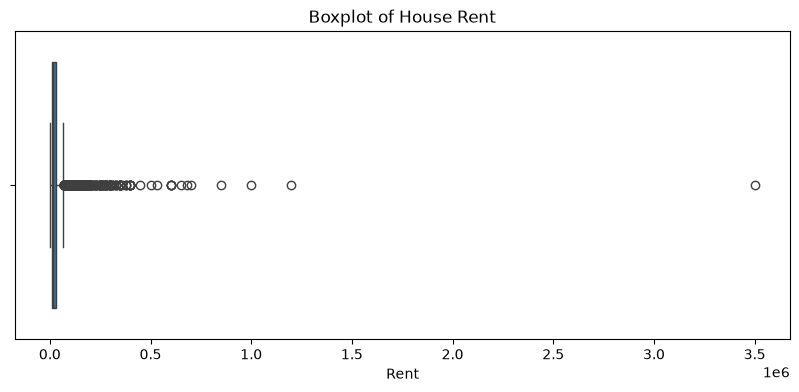

In [81]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df_house['Rent'])

plt.title('Boxplot of House Rent')
plt.xlabel('Rent')
plt.show()

# **Actual vs Predicted Graph**

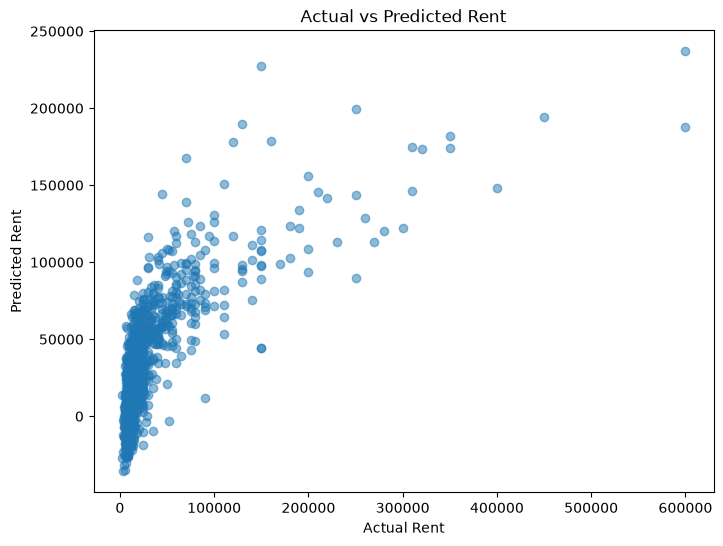

In [82]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, pred, alpha=0.5)

plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Actual vs Predicted Rent')

plt.show()

# **Regression Model**

In [6]:
import joblib

In [16]:
X = df.drop('Rent', axis=1)
y = df['Rent']

In [17]:
X = pd.get_dummies(X, drop_first=True)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [20]:
joblib.dump(model, 'ml_model.pkl')

['ml_model.pkl']

# **LabelEncoder**

In [29]:
joblib.dump(model, 'ml_model.pkl')


['ml_model.pkl']

In [11]:
df.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='str')

In [1]:
import os
print(os.path.abspath("label_encoders.pkl"))


C:\Users\Administrator\label_encoders.pkl


In [23]:
import joblib

joblib.dump(model, "rent_model.pkl")

['rent_model.pkl']

In [24]:
df.select_dtypes(include='object').columns

C:\Users\Administrator\AppData\Local\Temp\ipykernel_5212\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['Posted On', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Point of Contact'],
      dtype='str')

In [25]:
import joblib

joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [26]:
print(X.columns.tolist())

['BHK', 'Size', 'Bathroom', 'Posted On_2022-04-23', 'Posted On_2022-04-24', 'Posted On_2022-04-25', 'Posted On_2022-04-26', 'Posted On_2022-04-27', 'Posted On_2022-04-28', 'Posted On_2022-04-29', 'Posted On_2022-04-30', 'Posted On_2022-05-01', 'Posted On_2022-05-02', 'Posted On_2022-05-03', 'Posted On_2022-05-04', 'Posted On_2022-05-05', 'Posted On_2022-05-06', 'Posted On_2022-05-07', 'Posted On_2022-05-08', 'Posted On_2022-05-09', 'Posted On_2022-05-10', 'Posted On_2022-05-11', 'Posted On_2022-05-12', 'Posted On_2022-05-13', 'Posted On_2022-05-14', 'Posted On_2022-05-15', 'Posted On_2022-05-16', 'Posted On_2022-05-17', 'Posted On_2022-05-18', 'Posted On_2022-05-19', 'Posted On_2022-05-20', 'Posted On_2022-05-21', 'Posted On_2022-05-22', 'Posted On_2022-05-23', 'Posted On_2022-05-24', 'Posted On_2022-05-25', 'Posted On_2022-05-26', 'Posted On_2022-05-27', 'Posted On_2022-05-28', 'Posted On_2022-05-29', 'Posted On_2022-05-30', 'Posted On_2022-05-31', 'Posted On_2022-06-01', 'Posted On_2

In [3]:
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv(r"C:\Users\Administrator\Downloads\House_Rent_Dataset.csv")

# Categorical columns
categorical_columns = [
    "Floor",
    "Area Type",
    "Area Locality",
    "City",
    "Furnishing Status",
    "Tenant Preferred"
]

# Create encoders dictionary
label_encoders = {}

# Fit separate encoder for each column
for column in categorical_columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column].astype(str))
    label_encoders[column] = le

# Save encoders
joblib.dump(label_encoders, "label_encoders.pkl")

print("Encoders saved successfully!")
print(type(label_encoders))
print(label_encoders.keys())

Encoders saved successfully!
<class 'dict'>
dict_keys(['Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred'])
